# **MODULO 1 — EDA: Análisis del Mercado Musical**


**Proyecto:** ProyectoFinal23 — Análisis del mercado musical para el artista  
**Fuentes de datos:** Last.fm API (principal) + AcousticBrainz API (enriquecimiento, subset)  
**Objetivo del módulo:** Entender patrones de popularidad y construir la base analítica para predecir hits.

### 🗓️ Historial de trabajo


| Semana | Qué se hizo |
|--------|-------------|
| Semana 1 | Definición del proyecto. Lluvia de ideas. Primer contacto con Last.fm API. |
| Semana 2 | Recolección multi-endpoint. Problema de datos insuficientes (<60k). Prueba de AcousticBrainz. |
| Semana 3 | Limpieza, feature engineering, EDA completo. Integración de datasets. |

#### Semana 1: 




##### Definición del proyecto y objetivos para encontrar la data


###### **Lluvia de ideas**
**1. RELATIVO A LA MÚSICA:**

* Predecir qué canción será el próximo éxito de verano.
* Análisis de mercado musical, orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).
* Detección de fraude en streams, mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.
* Detector de copyright basado en inteligencia artificial, capaz de identificar la presencia de contenido musical en diferentes plataformas digitales mediante técnicas de procesamiento de audio, como espectrogramas y huellas digitales (audio fingerprinting), inspirado en tecnologías utilizadas por empresas como Shazam..

**2. RELATIVO A CREACIÓN DE CONTENIDO EN STREAM:**
* Muchos creadores de contenido streaming no saben a qué hora emitir ni qué jugar para maximizar su audiencia.

**3. RELATIVO A LA PRESENCIA DE OVNIS EN LA HISTORIA:**
* Avistamiento de ovnis: clasificar si un avistamiento es un "Fenómeno Atmosférico/Aeronáutico Explicable" o un "Incidente Inexplicable (Misterio)" basado en cómo fue descrito y el clima de ese momento.
**DECIDIMOS COMO PROYECTO: TRES MODULOS INICIALES**
* Analisis del mercado musical apra el artista
* Fraude en streams
* Predecir qué canción será el próximo éxito de verano
####### **Propuesta inicial**

* DEFINICIÓN Y OBJETIVOS PARA LA BÚSQUEDA DE DATOS

En un contexto donde plataformas como Spotify o YouTube concentran gran parte del consumo musical, los artistas independientes enfrentan desafíos relacionados con la transparencia en los ingresos, la detección de usos no autorizados de su obra y la optimización de sus estrategias de lanzamiento. Este proyecto propone abordar estas problemáticas mediante el desarrollo de dos módulos principales basados en datos existentes. Los módulos son:

**Módulo 1. Analisis del mercado musical apra el artista: Predecir qué canción será el próximo éxito de verano** 

* Análisis de mercado musical orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).
* Posibles datos para el análisis: Streams por país, Género musical, Playlist placement, TikTok trends, Crecimiento de artistas similares...
* Análisis (EDA): crecimiento por género, países con más crecimiento, correlación entre playlist y streams, horas/días con más reproducciones
* ML posible: Predicción de streams de una canción, Predicción de viralidad, 
* Modelos: Random Forest, XGBoost, LSTM para series temporales

Predicción:
* Paso 1 (El Problema): Predecir la popularidad (de 0 a 100) de una canción o clasificar a qué género musical exacto pertenece basándose únicamente en sus características acústicas.
* Paso 2 (Obtención): Usar la API de Spotify. Es facilísimo extraer más de 60.000 canciones. La API te devuelve variables fascinantes: danceability (bailabilidad), energy, acousticness, instrumentalness, liveness, valence (positividad), tempoduración, explícito (variable categórica), etc. Si las cruzas con otra API (como Genius para contar palabras en la letra), pasas de las 20 variables sobradamente.
* Paso 3 (Almacenamiento): Guardar todo en una base de datos relacional (como PostgreSQL o MySQL). Puedes crear tablas separadas para "Artistas", "Álbumes" y "Tracks" y hacer consultas JOIN para unirlo todo en Python.
* Paso 7 (La App Web): Una web en Streamlit donde el jurado pueda introducir el enlace de una canción de Spotify (o subir un archivo de audio si te animas a procesarlo) y la app les diga con un gráfico de barras qué nivel de éxito tendría y qué emociones transmite el modelo.

**Módulo 2. Fraude en streams:**

* Detección de fraude en streams mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.


       
###### **PROBLEMAS DURANTE LA BÚSQUEDA DE DATOS**
Primera prueba del proyecto - ipynb "Modulo 1_backup_manual_data":

**· Problema 1 & Resolución:** Identificamos que no es viable hacer focus en tres modulos así que reducimos a dos: Análisis del mercado musical y Fraude en streams.


**· Problema 2:** Descarga de información de usuarios.
* Se planteó el problema de conseguir datos de más usuarios.

**Resolución de la descarga de información de usuarios:** Se define una función para buscarlos entre los amigos del usuario llamado "rj" creando así una red de usarios conectados.

**· Problema 3:** Al revisar el código y la información que devuelve se observa que:
* 

#### Semana 2: Inspeccionando la data



###### TRATANDO DATA DE LAS APIS
**· Problema 1:** Descarga de datos con API Lastfm: 
* Inicialmente se utilizan los endpoints "chart.getTopTracks","geo.getTopTracks", "tag.getTopTracks" y "track.getInfo".
* Se han hecho varias pruebas de descarga de datos con el objetivo de análisis de los tracks en el mercado musical según streams, popularidad y escuchas pero se ha encontrado data insuficiente con muchos valores faltantes, con respuestas muy generales o poco coherentes para el análisis.

**Resolución de la descarga de datos:** Búsqueda de nuevas apis para enfocar mejor el análisis y obtener más data. Se decide utilizar Acousticbrainz porque contiene la metadata de cada track. 

**· Problema 2:** Descarga de datos con Acousticbrainz:
* Se intenta recolectar data de los endpoints "Low-level " y "High-level" que devuelven la información del bpm, key, scale,danceability, mood_happy y genre_ab.
* Al analizar una muestra de 500 datos se oberva que existen nulos en todas las columnas menos en mbid. Esto indica que de las canciones que tenemos en el csv de Lastfm no hay data. Es posible que sea debido a que la misma base de datos dónde buscamos la metadata se dejó de actualizar antes que Lastfm."

**Resolución:** 
* Ideas, (1) utilizar solamente api acousticbrainz con data antigua com prueba... 

(2) intentar hacer web scrapping se paginas como Bandcamp o Nina Protocol.

Last.fm → popularidad (mainstream)

AcousticBrainz → características audio

Bandcamp → géneros + país

Nina → tendencias + escenas underground. Complementa a la data de LAst.fm porque añade la infromacion de las tendencias y el consumo mainstream de usuarios.

* Entre Bandcamp y Nina

| Feature        | Bandcamp | Nina                  |
| -------------- | -------- | --------------------- |
| Géneros        | ✅        | ⚠️ menos estructurado |
| País           | ✅        | ⚠️ depende            |
| Trends         | ⚠️       | ✅ MUY fuerte          |
| Underground    | ⚠️       | ✅ fuerte              |
| Datos abiertos | ❌        | ✅                     |




#### Semana 3

**REvisión de data y endpoints:** “El endpoint geo.getTopTracks no proporciona el país de origen del track, sino el ranking dentro de un país. Por ello, la variable ‘country’ se interpreta como contexto geográfico de popularidad y no como origen del artista.”
**Solución:** Usar Endpoint distinto para encontrar el país enlazado al artista

### Índice del proyecto

1. [Setup e imports](#setup)
2. [Carga y vista general del dataset](#carga)
3. [Calidad de datos — Missing values y limpieza](#calidad)
4. [Feature Engineering](#features)
5. [EDA — Análisis de popularidad](#popularidad)
6. [EDA — Relación entre variables](#relaciones)
7. [EDA — Análisis por país](#pais)
8. [EDA — Análisis por género](#genero)
9. [EDA — AcousticBrainz (subset enriquecido)](#acousticbrainz)
10. [Resumen de insights](#resumen)

* **ML:** Predicción de streams de una canción, Predicción de viralidad, 
    * Modelos: Random Forest, XGBoost, LSTM para series temporales

* Output: “Tu canción tiene 65% probabilidad de viralizarse en México”, “Este beat funciona mejor en playlist de chill trap”


# **DATA**


---
## 1. Setup e imports <a id='setup'></a>

In [11]:
# ── Librerías ────────────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print('Setup completo')

Setup completo


---
## 2. Carga y vista general del dataset <a id='carga'></a>

El dataset ha sido construido combinando tres endpoints de Last.fm para alcanzar el mínimo de 60.000 registros:

**Endpoints usados:**

| Endpoint | Datos | Uso | Técnicas aplicadas 
|---|---|---|--- |
| `chart.getTopTracks` | Top global  | Top canciones/artistas por periodo |Throttling, retry/backoff, paginación | |
| `chart.getTopArtists` | Top global (paginado) | Top canciones/artistas por periodo |Throttling, retry/backoff, paginación | |
| `geo.getTopTracks` | Top por país | Análisis geográfico |Batch por lista de países| |
| `tag.getWeeklyChartList` | Evolución temporal | ~15.000 | Batch por lista de tags| |
| `chart.getTopTags` | Análisis de géneros (crecimiento&decrecimiento) | enriquece los anteriores | | 


**Decisión de diseño:** se eliminan columnas irrelevantes para el análisis (`image`, `streamable`, `url`) ya en la fase de ingesta, antes de llegar al EDA.

### Explicación de los Endpoints 

Parámetros API:

1. country (Required) : A country name, as defined by the ISO 3166-1 country names standard
2. location (Optional) : A metro name, to fetch the charts for (must be within the country specified)
3. limit (Optional) : The number of results to fetch per page. Defaults to 50.
4. page (Optional) : The page number to fetch. Defaults to first page.
5. api_key (Required) : A Last.fm API key.

Retornos de cada Endpoint (lista de diccionarios):

1. chart.getTopTracks y chart.getTopArtists:
* Devuelven los elementos más populares globalmente en el momento de la consulta,
* Datos clave: name, artist.name, playcount, listeners, mbid, duration. Las variables con mayor relevancia para conocer la popularidad de los tracks son playcount y listener.
2. chart.getTopTags: https://www.last.fm/api/show/geo.getTopTracks 
* Devuelve canciones populares por país y aporta diversidad cultural al dataset.
* El parámetro clave es country. Será la segmentación musical del análisis.
3. tag.getTopTracks: https://www.last.fm/api/show/tag.getTopTags 
* Devuelve canciones populares por género/tag y permite comparar los resultados diferentes momentos para identificar qué etiquetas están ganando tracción.
.
* Variable clave: genre_tag.

*Evolución temporal: Para ver tendencias a lo largo del tiempo, el endpoint tag.getWeeklyChartList es clave, ya que permite obtener una lista de los charts semanales disponibles para etiquetas específicas (géneros)*


4. track.getInfo: https://www.last.fm/api/show/track.getInfo
* Devuelve información adicional de cada track --> duraction, ...DUDA cuales mas como saberlo?


Variables Principales API:

In [12]:
API_KEY = '63e059c3c912a3f642daf2372484d183'
BASE_URL = 'http://ws.audioscrobbler.com/2.0/'
DELAY = 0.5  


### Data base para el análisis:

#### *Teoria: Función general para hacerpeticiones API con retry y backoff exponencial.*




**Objetivo:** Realizar peticiones API evitando errores de rate limits, de servidor y problemas de red.

**Parámetros:**

* params   — dict con los parámetros de la petición (method, page, etc.).
    * base_params = {'api_key': API_KEY, 'format': 'json'}
        * api_key → autenticación
        * format=json → respuesta en formato JSON
    * base_params.update(params), se añaden los parámetros específicos de cada llamada.

* retries  — número máximo de reintentos ante errores de servidor. 

**Bucle:** 

* attempt — número de intentos por petición de cada dato, se usa para contar intentos y calcular el tiempo de espera (backoff).

* try: requests.get(BASE_URL, params=base_params, timeout=10) — Evita que el programa se quede bloqueado.
        - BASE_URL, endpoint de Last.fm.
        * params, parámetros de la API.
        * timeout=10, máximo 10 segundos de espera.

**Condición del bucle:** Para resolver los "server-side errors", errores del servidor al hacer las peticiones.

* **Manejo de errores:** response.status_code in [429, 500, 502, 503, 504]
    * 429, demasiadas peticiones (rate limit).
    * 500–504, errores del servidor.

    * **Backoff exponencial:** wait = 2 ** attempt & time.sleep(wait) marcan el tiempo de espera despues de cada intento de petición permitiendo al servidor recuperarse.
    * continue, salta al siguiente intento del bucle sin romper / parar la función.

* Retorna el JSON de la respuesta o None si falla definitivamente.
    * response.raise_for_status(), es la validación de la respuesta. Si hay error HTTP "lanza expedicion" DUDA si no continua.
    * return response.json(), convierte la respuesta en diccionario Python y devuelve los datos de la API.

* **Manejo de errores en la red:** * except requests.exceptions.RequestException as e — captura errores de timeout, desconexión o DNS error. Se utiliza el mismo sitmea backoff exponencial que en los errores de servidor para resolver los problemas.
     

* Si todos los intentos fallas aparece un mensaje aparece un mensaje con el numero de intentos y devuelve None como dato.

Conceptos clave de la API:

- **Throttling** → ir lento a propósito para no superar el rate limit
- **Backoff exponencial** → esperar 2s, 4s, 8s... si hay error
- **Paginación** → iterar por páginas para obtener todos los datos
- **Deduplicación** → eliminar duplicados entre endpoints
- **Timeout** → evitar bloqueos
- **HTTP status codes** → interpretar respuestas

#### Función inicial: Errores en las peticiones

In [13]:
def fetch_lastfm(params: dict, retries: int = 5) -> dict | None:
 
    base_params = {'api_key': API_KEY, 'format': 'json'}
    base_params.update(params)

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=base_params, timeout=10)

            # Códigos que merecen reintento (server-side errors)
            if response.status_code in [429, 500, 502, 503, 504]:
                wait = 2 ** attempt
                print(f'  ⚠️  HTTP {response.status_code} → retry en {wait}s (intento {attempt+1}/{retries})')
                time.sleep(wait)
                continue

            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            wait = 2 ** attempt
            print(f'  ⚠️  Error de red: {e} → retry en {wait}s')
            time.sleep(wait)

    print(f'Fallo definitivo tras {retries} intentos')
    return None

#### Función para Endpoint chart.getTopTracks

In [14]:
def fetch_top_tracks(page=1, limit=200, retries=5):
    params = {'method': 'chart.getTopTracks','api_key': API_KEY,'format': 'json','page': page,'limit': limit}

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=params, timeout=10)

            if response.status_code in [429, 500, 502, 503]:
                wait_time = 2 ** attempt
                print(f"[{response.status_code}] Retry en {wait_time}s...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            print(f"Error: {e}")
            time.sleep(2 ** attempt)

    print(f"❌ Fallo total en página {page}")
    return None

In [15]:
fetch_top_tracks()

{'tracks': {'track': [{'name': 'Stateside + Zara Larsson',
    'duration': '176',
    'playcount': '15843882',
    'listeners': '1059365',
    'mbid': 'ffbf7862-2476-4164-ac32-f5904ccefe0f',
    'url': 'https://www.last.fm/music/PinkPantheress/_/Stateside+%252B+Zara+Larsson',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'PinkPantheress',
     'mbid': '7441014f-f8f5-494f-81db-ff166fbc078d',
     'url': 'https://www.last.fm/music/PinkPantheress'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}]},
   {'name': 'S

#### No repetir datos del csv existentes


In [16]:
if os.path.exists("backup_manual.csv"):
    df_existing = pd.read_csv("backup_manual.csv")
else:
    df_existing = pd.DataFrame()

In [17]:
# crea conjunto de canciones existentes:
existing_tracks = set()

if not df_existing.empty:
    for _, row in df_existing.iterrows():
        key = f"{row['name']}_{row['artist']}"
        existing_tracks.add(key)

In [18]:
df_existing.head()

,name,duration,playcount,listeners,mbid,url,streamable,artist,image,country,genre_tag
0,Stateside + Zara Larsson,176,14787193.0,1013640.0,ffbf7862-2476-4164-ac32-f5904ccefe0f,https://www.last.fm/music/PinkPantheress/_/Sta...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
1,Body to Body,189,2615165.0,250542.0,6dfdfc61-89ff-451a-a5e9-5319065beae7,https://www.last.fm/music/BTS/_/Body+to+Body,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
2,Hooligan,182,2367820.0,233389.0,a045f252-ea1a-42c3-b7a5-f69979e39394,https://www.last.fm/music/BTS/_/Hooligan,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
3,Swim,159,6050938.0,231653.0,6f33dc05-cdc0-4a2f-8039-e8fed082eec6,https://www.last.fm/music/BTS/_/Swim,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
4,FYA,180,2324099.0,227425.0,802e86e2-5da4-40c5-a265-933eb64d864b,https://www.last.fm/music/BTS/_/FYA,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN


#### Batch & DataFrame para characteristics TopTracks

* Por cada página se descargan 200 canciones.

In [19]:
all_tracks = []

for page in range(1, 50):  # empieza pequeño

    data = fetch_top_tracks(page=page)

    if data is None:
        print(f"⚠️ Saltando página {page}")
        time.sleep(5)
        continue

    tracks = data.get('tracks', {}).get('track', [])

    for track in tracks:
        name = track.get('name')
        artist = track.get('artist', {}).get('name')

        key = f"{name}_{artist}"

        # Evitar duplicados
        if key in existing_tracks:
            continue

        all_tracks.append({
            'name': name,
            'artist': artist,
            'playcount': track.get('playcount'),
            'listeners': track.get('listeners'),
            'mbid': track.get('mbid'),
            'duration': track.get('duration'),
            'url': track.get('url')
        })

        existing_tracks.add(key)

    time.sleep(DELAY)

    # Guardado frecuente
    if page % 10 == 0:
        df_temp = pd.DataFrame(all_tracks)
        df_total = pd.concat([df_existing, df_temp], ignore_index=True)
        df_total.to_csv("backup_manual.csv", index=False)
        print(f"Guardado en página {page}")

Guardado en página 10
Guardado en página 20
Guardado en página 30
Guardado en página 40


* Guardado frecuente

In [20]:
df_new = pd.DataFrame(all_tracks)
df_final = pd.concat([df_existing, df_new], ignore_index=True)

df_final.drop_duplicates(subset=['name', 'artist'], inplace=True)

df_final.to_csv("backup_manualt.csv", index=False)

print("Recolección completada")

Recolección completada


#### Erroes API 23-03-2026:

* Errores en peticiones:

| Código | Significado | Quién tiene el problema     |
| ------ | ----------- | --------------------------- |
| 403    | Forbidden   | ❌ tú (API key, permisos)    |
| 429    | Rate limit  | ⚠️ tú (demasiadas requests) |
| 502    | Bad Gateway | ❌ servidor (Last.fm)        |

* Errores después de obtener data: 
    - Bug en menos de 10K datos
    - Solucionar problema y no volver a guardar data duplicada
    - Descarga de datos sigue siendo insuficiente. Tenemos menos de 20K y necesitamos 60K. (Error 2 en doc ERRORS -> Solución: Combinar fuentes).

* Solucionar ERROR 2: descarga de data de más generos y países para completar las filas faltantes con información de valores para el análisis.


### Data por países:

#### Función data países:

In [28]:
def fetch_geo_tracks(country, page=1, limit=200, retries=5):
    params = {
        'method': 'geo.getTopTracks',
        'country': country,
        'api_key': API_KEY,
        'format': 'json',
        'page': page,
        'limit': limit
    }

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=params, timeout=10)

            if response.status_code in [429, 500, 502, 503]:
                time.sleep(2 ** attempt)
                continue

            response.raise_for_status()
            return response.json()

        except:
            time.sleep(2 ** attempt)

    return None

In [ ]:
all_tracks = []

for page in range(1, 50):  # empieza pequeño

    data = fetch_geo_tracks(country,page=page)

    if data is None:
        print(f"⚠️ Saltando página {page}")
        time.sleep(5)
        continue

    tracks = data.get('tracks', {}).get('track', [])

    for track in tracks:
        name = track.get('name')
        artist = track.get('artist', {}).get('name')

        key = f"{name}_{artist}"

        # Evitar duplicados
        if key in existing_tracks:
            continue

        all_tracks.append({
            'name': name,
            'artist': artist,
            'playcount': track.get('playcount'),
            'listeners': track.get('listeners'),
            'mbid': track.get('mbid'),
            'duration': track.get('duration'),
            'url': track.get('url'),
            'country': country
        })

        existing_tracks.add(key)

    time.sleep(DELAY)

    # Guardado frecuente
    if page % 10 == 0:
        df_temp = pd.DataFrame(all_tracks)
        df_total = pd.concat([df_existing, df_temp], ignore_index=True)
        df_total.to_csv("backup_manual.csv", index=False)
        print(f"Guardado en página {page}")

TypeError: fetch_geo_tracks() missing 1 required positional argument: 'country'

#### Lista por paises:

In [ ]:
# countries = ['Spain', 'United States', 'United Kingdom', 'Brazil', 'Germany', 'France', 'Mexico', 'Peru', 'Japan', 'Netherlands']

# for country in countries:
#     print(f"🌍 País: {country}")

#     for page in range(1, 20):

#         data = fetch_geo_tracks(country, page)

#         if data is None:
#             continue

#         tracks = data.get('tracks', {}).get('track', [])

#         for track in tracks:
#             name = track.get('name')
#             artist = track.get('artist', {}).get('name')

#             key = f"{name}_{artist}"

#             if key in existing_tracks:
#                 continue

#             all_tracks.append({
#                 'name': name,
#                 'artist': artist,
#                 'playcount': track.get('playcount'),
#                 'listeners': track.get('listeners'),
#                 'mbid': track.get('mbid'),
#                 'duration': track.get('duration'),
#                 'url': track.get('url'),
#                 'country': country
#             })

#             existing_tracks.add(key)

#         time.sleep(DELAY)

🌍 País: Spain


NameError: name 'existing_tracks' is not defined

In [ ]:
countries = ['Spain', 'United States', 'United Kingdom', 'Brazil', 'Germany', 'France', 'Mexico', 'Peru', 'Japan', 'Netherlands']
fetch_geo_tracks('Japan')

{'tracks': {'track': [{'name': 'Swim',
    'duration': '159',
    'listeners': '1220',
    'mbid': '6f33dc05-cdc0-4a2f-8039-e8fed082eec6',
    'url': 'https://www.last.fm/music/BTS/_/Swim',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'BTS',
     'mbid': '0d79fe8e-ba27-4859-bb8c-2f255f346853',
     'url': 'https://www.last.fm/music/BTS'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}],
    '@attr': {'rank': '0'}},
   {'name': 'Body to Body',
    'duration': '189',
    'listeners': '1090',
    'mbid': '6dfdfc

In [ ]:
fetch_geo_tracks('Spain')

{'tracks': {'track': [{'name': 'Stateside + Zara Larsson',
    'duration': '176',
    'listeners': '4789',
    'mbid': 'ffbf7862-2476-4164-ac32-f5904ccefe0f',
    'url': 'https://www.last.fm/music/PinkPantheress/_/Stateside+%252B+Zara+Larsson',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'PinkPantheress',
     'mbid': '7441014f-f8f5-494f-81db-ff166fbc078d',
     'url': 'https://www.last.fm/music/PinkPantheress'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}],
    '@attr': {'rank': '0'}},
   {'name': 'Swim'

In [ ]:
FILE_NAME = 'backup_manual.csv'
df_new = pd.DataFrame(all_tracks)
df_final = pd.concat([df_existing, df_new], ignore_index=True)

df_final.drop_duplicates(subset=['name', 'artist'], inplace=True)

df_final.to_csv(FILE_NAME, index=False)

print("Datos de géneros guardados")

Datos de géneros guardados


### Data por género musical:

#### Funcion género musical

In [ ]:
def fetch_tag_tracks(tag, page=1, limit=200, retries=5):
    params = {
        'method': 'tag.getTopTracks',
        'tag': tag,
        'api_key': API_KEY,
        'format': 'json',
        'page': page,
        'limit': limit
    }

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=params, timeout=10)

            if response.status_code in [429, 500, 502, 503]:
                wait_time = 2 ** attempt
                print(f"[{response.status_code}] Retry en {wait_time}s...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            print(f"Error: {e}")
            time.sleep(2 ** attempt)

    print(f"Fallo en tag {tag}, página {page}")
    return None

In [ ]:
def get_top_tags():
    params = {
        'method': 'tag.getTopTags',
        'api_key': API_KEY,
        'format': 'json'
    }

    response = requests.get(BASE_URL, params=params)
    data = response.json()

    tags = [tag['name'] for tag in data['toptags']['tag']]
    return tags

tags = get_top_tags()
print(tags[:21])

['rock', 'electronic', 'seen live', 'alternative', 'pop', 'indie', 'female vocalists', 'metal', 'alternative rock', 'jazz', 'classic rock', 'ambient', 'experimental', 'folk', 'indie rock', 'punk', 'Hip-Hop', 'hard rock', 'black metal', 'instrumental', 'singer-songwriter']


In [ ]:
tags = ['rock', 'electronic', 'seen live', 'alternative', 'pop', 'indie', 'female vocalists', 'metal', 'alternative rock', 'jazz', 'classic rock', 'ambient', 'experimental', 'folk', 'indie rock', 'punk', 'Hip-Hop', 'hard rock', 'black metal', 'instrumental', 'singer-songwriter']

for tag in tags:
    print(f"🎧 Género: {tag}")

    for page in range(1, 20):

        data = fetch_tag_tracks(tag, page)

        if data is None:
            continue

        tracks = data.get('tracks', {}).get('track', [])

        for track in tracks:
            name = track.get('name')
            artist = track.get('artist', {}).get('name')

            key = f"{name}_{artist}"

            # 🚫 evitar duplicados
            if key in existing_tracks:
                continue

            all_tracks.append({
                'name': name,
                'artist': artist,
                'playcount': track.get('playcount'),
                'listeners': track.get('listeners'),
                'mbid': track.get('mbid'),
                'duration': track.get('duration'),
                'url': track.get('url'),
                'country': 'TAG',
                'genre_tag': tag
            })

            existing_tracks.add(key)

        time.sleep(DELAY)

    print(f"Completado género: {tag}")

🎧 Género: rock
Completado género: rock
🎧 Género: electronic
Completado género: electronic
🎧 Género: seen live
Completado género: seen live
🎧 Género: alternative
Completado género: alternative
🎧 Género: pop
Completado género: pop
🎧 Género: indie
Completado género: indie
🎧 Género: female vocalists
Completado género: female vocalists
🎧 Género: metal
Completado género: metal
🎧 Género: alternative rock
Completado género: alternative rock
🎧 Género: jazz
Completado género: jazz
🎧 Género: classic rock
Completado género: classic rock
🎧 Género: ambient
Completado género: ambient
🎧 Género: experimental
Completado género: experimental
🎧 Género: folk
Completado género: folk
🎧 Género: indie rock
Completado género: indie rock
🎧 Género: punk
Completado género: punk
🎧 Género: Hip-Hop
Completado género: Hip-Hop
🎧 Género: hard rock
Completado género: hard rock
🎧 Género: black metal
Completado género: black metal
🎧 Género: instrumental
Completado género: instrumental
🎧 Género: singer-songwriter
Completado

In [ ]:
df_new = pd.DataFrame(all_tracks)
df_final = pd.concat([df_existing, df_new], ignore_index=True)

df_final.drop_duplicates(subset=['name', 'artist'], inplace=True)

df_final.to_csv(FILE_NAME, index=False)

print("Datos de géneros guardados")

NameError: name 'all_tracks' is not defined

In [ ]:
import pandas as pd
df_final = pd.read_csv('backup_manual.csv')

/tmp/ipykernel_1294/1401388933.py:2: DtypeWarning: Columns (0: streamable, 1: image) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('backup_manual.csv')


In [ ]:
df_final.shape

(100228, 11)

# **EDA**

## Indíce EDA:

1. **Análisis del mercado musical (descriptivo):** 

(1) Top canciones / artistas por periodo (tiempo); 

(2) Evolución temporal de popularidad; 

(3) Géneros en crecimiento vs decrecimiento

2. **Análisis por género:**

* Distribución de features por género: danceability, energy, valence, tempo

* ¿Qué hace único a cada género?

3. **Análisis geográfico** 

(1) Países con mayor consumo; 

(2) Diferencias culturales en features.

4. **Ciclos de éxito:** 

(1) Duración de popularidad de una canción; 

(2) Tiempo entre picos de streams; 

(3) Estacionalidad (ej: “hits de verano”)

**Features engineering (clave para predecir un hit):**


1. **Correlación con popularidad:** Qué variables impactan más: danceability ↑, energy ↑, valence (positivo vs triste)

* Heatmap de correlaciones

2. **Ingeniería de variables:** (1) Ratio energía/valence; (2) Duración normalizada; (3) Explicit vs no explicit; (4) Features agregadas por artista

3. **Segmentación de canciones:** 

* Clustering para KMeans
* Tipos de canciones: “club hit”, “chill”, “sad viral”,... 

## Análisis

### Paso 0. **Información y limpieza del DataFrame**

#### **Información general:**

In [ ]:
df = df_final.copy()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100487 entries, 0 to 100486
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   name        100487 non-null  str   
 1   duration    100487 non-null  object
 2   playcount   20058 non-null   object
 3   listeners   25272 non-null   object
 4   mbid        89428 non-null   str   
 5   url         100487 non-null  str   
 6   streamable  9999 non-null    str   
 7   artist      100485 non-null  str   
 8   image       9999 non-null    str   
 9   country     80429 non-null   str   
 10  genre_tag   75215 non-null   str   
dtypes: object(3), str(8)
memory usage: 8.4+ MB


In [ ]:
df.head()

,name,duration,playcount,listeners,mbid,url,streamable,artist,image,country,genre_tag
0,Stateside + Zara Larsson,176,14787193.0,1013640.0,ffbf7862-2476-4164-ac32-f5904ccefe0f,https://www.last.fm/music/PinkPantheress/_/Sta...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
1,Body to Body,189,2615165.0,250542.0,6dfdfc61-89ff-451a-a5e9-5319065beae7,https://www.last.fm/music/BTS/_/Body+to+Body,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
2,Hooligan,182,2367820.0,233389.0,a045f252-ea1a-42c3-b7a5-f69979e39394,https://www.last.fm/music/BTS/_/Hooligan,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
3,Swim,159,6050938.0,231653.0,6f33dc05-cdc0-4a2f-8039-e8fed082eec6,https://www.last.fm/music/BTS/_/Swim,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN
4,FYA,180,2324099.0,227425.0,802e86e2-5da4-40c5-a265-933eb64d864b,https://www.last.fm/music/BTS/_/FYA,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb...",[{'#text': 'https://lastfm.freetls.fastly.net/...,NaN,NaN


> **Observaciones:**  
> * Tenemos un total de 100228 filas y 11 columnas:  
>   - Columnas numéricas: duration, playcount, listeners (variables clave)  
>   - Columnas string: name, image, country, streamable,genre_tag (etiquetas)  
>   - Columnas identificadoras: url, mbid (código identificador)
> * Valores nulos: Las filas que contienen más valores nulos son playcount, listeners y mbid. 


**Descripción de variables del dataset:** 


>**Variables principales:**
> 
> * **name** Nombre de la canción. Identificador principal del track.
> 
> * **artist** Nombre del artista. Permite agrupar por creador y analizar popularidad.
> 
> * **playcount** Número total de reproducciones. (Indicador directo de popularidad global)
> 
> * **listeners** Número de usuarios únicos que han escuchado la canción. (Permite medir alcance real (no solo repeticiones))
> 
> * **duration** Duración de la canción en milisegundos.(Útil para analizar tendencias (ej: canciones cortas tipo TikTok))

---

> **Variables contextuales**
> 
> * **country** País desde donde se recoge el dato. (Permite análisis geográfico del mercado musical.)
> 
> * **genre_tag** Género musical asociado (tag de Last.fm). (Permite segmentar por estilo musical.)

---

> **Variables técnicas**
> 
> * **mbid** Identificador único de MusicBrainz. (Sirve para eliminar duplicados con precisión.)
> 
> * **url** Enlace a la canción en Last.fm. (No aporta valor analítico directo.)

---

> **Variables descartadas**
> 
> * **streamable** Indica si la canción es reproducible. (No aporta valor para análisis de popularidad.)
> 
> * **image** Imagen del track/artista. (Irrelevante para análisis numérico.)

---



#### **Limpieza de datos:**

In [ ]:
df_clean = df

* Duplicados:


In [ ]:
df_clean.drop_duplicates(subset=['name', 'artist'], inplace=True)

print("Después de duplicados:", df_final.shape)

Después de duplicados: (100487, 11)


* Valores nulos:

In [ ]:
df_clean.isnull().sum()

name              0
duration          0
playcount     80429
listeners     75215
mbid          11059
url               0
streamable    90488
artist            2
image         90488
country       20058
genre_tag     25272
dtype: int64

In [ ]:
df_clean = df.dropna(subset=['playcount', 'listeners']).copy()

print("Dataset limpio:", df_clean.shape)

Dataset limpio: (20058, 11)


* Se eliminan las columnas que no son relevantes para el análisis:

In [ ]:
df_clean.drop(['image','url','mbid'],axis=1).copy()

,name,duration,playcount,listeners,streamable,artist,country,genre_tag
25013,Telephone (feat. Beyoncé),221,NaN,NaN,NaN,Lady Gaga,TAG,pop
25014,California Gurls (feat. Snoop Dogg),235,NaN,NaN,NaN,Katy Perry,TAG,pop
25015,Blow,219,NaN,NaN,NaN,Ke$ha,TAG,pop
25016,We Found Love (feat. Calvin Harris),216,NaN,NaN,NaN,Rihanna,TAG,pop
25017,Die Young,213,NaN,NaN,NaN,Ke$ha,TAG,pop
...,...,...,...,...,...,...,...,...
100223,Sleeping Heart,208,NaN,NaN,NaN,Giles Corey,TAG,singer-songwriter
100224,Come in with the Rain,238,NaN,NaN,NaN,Taylor Swift,TAG,singer-songwriter
100225,Maybe Angels,371,NaN,NaN,NaN,Sheryl Crow,TAG,singer-songwriter
100226,Shiver Me Timbers,261,NaN,NaN,NaN,Tom Waits,TAG,singer-songwriter


* Valores nulos en country y genre_tag:

In [ ]:
# df_clean['country'].fillna('UNKNOWN')
# df_clean['genre_tag'].fillna('UNKNOWN')

In [ ]:
df_clean = df.dropna(subset=['country', 'genre_tag']).copy()

In [ ]:
df_clean.isnull().sum()

name              0
duration          0
playcount     75215
listeners     75215
mbid           4526
url               0
streamable    75215
artist            2
image         75215
country           0
genre_tag         0
dtype: int64

* En algunas filas se encuentra información guardada en diccionarios y solo queremos visualizar un dato:


In [ ]:
df_clean['artist'][0]

"{'name': 'PinkPantheress', 'mbid': '7441014f-f8f5-494f-81db-ff166fbc078d', 'url': 'https://www.last.fm/music/PinkPantheress'}"

In [ ]:
# df_clean['streamable'][0]

DUDA, ME HE QUEDAD OCN MENOS DE 20k DATOS PARA EL ANALISSI PERO EN LA COLUMNA ARTIST HAY UN IDENTIFICADOR, COMO MIRAR SI ME SIRVE PARA USAR MAS DATOS?

PROBBLEMA: serialización / deserialización de datos
df_music['artist'] = df_clean['artist'].apply(lambda x: x['name'] if isinstance(x, dict) else x) # NO DEVUELVE EL RESULTADO ESPERADO
👉 La API devuelve dict
👉 pero al guardar en CSV → se convierte en string
SOLUCION: primero convertir ese string en dict real

In [ ]:
import ast

def clean_artist(x):
    try:
        if isinstance(x, str) and x.startswith('{'):
            x = ast.literal_eval(x)
        return x.get('name') if isinstance(x, dict) else x
    except:
        return None
    
def clean_streamable(x):
    try:
        if isinstance(x, str) and x.startswith('{'):
            x = ast.literal_eval(x)
        return x.get('#text') if isinstance(x, dict) else x
    except:
        return None

In [ ]:
clean_streamable(df_clean['streamable'])

25013    NaN
25014    NaN
25015    NaN
25016    NaN
25017    NaN
          ..
100223   NaN
100224   NaN
100225   NaN
100226   NaN
100227   NaN
Name: streamable, Length: 75215, dtype: float64

In [ ]:
clean_artist(df_clean['artist'])

25013           Lady Gaga
25014          Katy Perry
25015               Ke$ha
25016             Rihanna
25017               Ke$ha
               ...       
100223        Giles Corey
100224       Taylor Swift
100225        Sheryl Crow
100226          Tom Waits
100227    Newton Faulkner
Name: artist, Length: 75215, dtype: str

In [ ]:
df_analysis = df_clean.drop(['image','url','mbid'],axis=1).copy()

##### **DUDA: DECISIÓN PARA ANÁLISIS, ELIMINO LOS NULOS DE PLAYCOUNT Y LISTENER AUNQUE SEAN DE LAS VARIABLES CON MÁS PESO?**

In [ ]:
# df_analysis = df_clean.dropna(subset=['playcount', 'listeners']).copy()

In [ ]:
# df_analysis['artist'] = df_clean['artist'].apply(lambda x: x['name'] if isinstance(x, dict) else x)
# df_analysis['streamable'] = df_clean['streamable'].apply(lambda x: x['#text'] if isinstance(x, dict) else x)
df_analysis.head()

,name,duration,playcount,listeners,streamable,artist,country,genre_tag
25013,Telephone (feat. Beyoncé),221,NaN,NaN,NaN,Lady Gaga,TAG,pop
25014,California Gurls (feat. Snoop Dogg),235,NaN,NaN,NaN,Katy Perry,TAG,pop
25015,Blow,219,NaN,NaN,NaN,Ke$ha,TAG,pop
25016,We Found Love (feat. Calvin Harris),216,NaN,NaN,NaN,Rihanna,TAG,pop
25017,Die Young,213,NaN,NaN,NaN,Ke$ha,TAG,pop


In [ ]:
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 75215 entries, 25013 to 100227
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        75215 non-null  str    
 1   duration    75215 non-null  object 
 2   playcount   0 non-null      object 
 3   listeners   0 non-null      object 
 4   streamable  0 non-null      float64
 5   artist      75213 non-null  str    
 6   country     75215 non-null  str    
 7   genre_tag   75215 non-null  str    
dtypes: float64(1), object(3), str(4)
memory usage: 4.6+ MB


In [ ]:
df_analysis.isna().sum()

name              0
duration          0
playcount     75215
listeners     75215
streamable    75215
artist            2
country           0
genre_tag         0
dtype: int64

> **Observaciones y decisiones:**
> * Se eliminaron duplicados por combinación de **name + artist**.
> * Se eliminaron registros sin **playcount** o **listeners**, ya que son variables clave para el análisis. -- **duda**
> * Se rellenaron valores faltantes en variables secundarias como **country** y **genre_tag**.
>
> **Justificación de eliminación de datos**
>
> Se eliminaron registros con valores nulos en variables clave (playcount, listeners) porque:
> 
> * Son esenciales para medir popularidad.
> * Su ausencia impide análisis estadísticos fiables. 
> * Introducen ruido y sesgos en modelos de machine learning.
>
> Este enfoque prioriza calidad sobre cantidad de datos.


### Paso 1. **Análisis del mercado musical (descriptivo):** 



(1) Top canciones / artistas por periodo (tiempo) 

(2) Evolución temporal de popularidad 

(3) Análisis por país

(3) Géneros en crecimiento vs decrecimiento

#### (1) Top canciones / artistas por periodo (tiempo)

#### (2) Evolución temporal de popularidad

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_analysis['playcount_log'] = np.log1p(df_analysis['playcount'])

plt.hist(df_analysis['playcount_log'], bins=50)
plt.title("Playcount (log)")
plt.show()

TypeError: loop of ufunc does not support argument 0 of type float which has no callable log1p method

##### Correlacion entre la popilaridad de las canciones

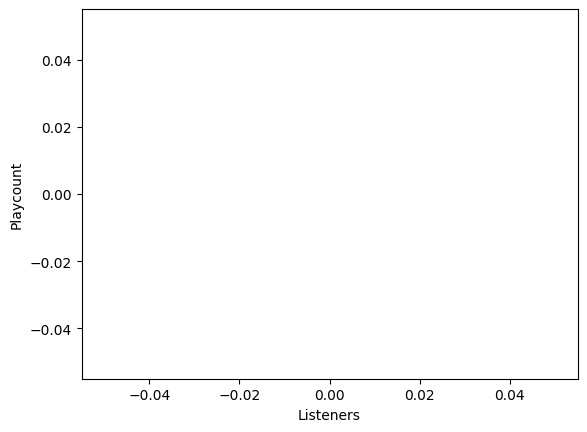

In [ ]:
plt.scatter(df_analysis['listeners'], df_analysis['playcount'], alpha=0.3)
plt.xlabel("Listeners")
plt.ylabel("Playcount")
plt.show()

> **Observaciones:** * Outliers presentes:... * correlacion positiva o engativa?

#### (3) Análisis por país

##### Procedencia de los artisitas top10:

 
* Oyentes de artists top10

**Info api request:**

In [ ]:
# API Request + Cuestiones generales (antes 23/03/2026)
ret_artist = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=geo.gettopartists&country=spain&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret_artist.json()
artists_country = pd.DataFrame(ret_artist.json()["topartists"]["artist"])
artists_country.head()


,name,listeners,mbid,url,streamable,image,@attr
0,Bad Bunny,12943,89aa5ecb-59ad-46f5-b3eb-2d424e941f19,https://www.last.fm/music/Bad+Bunny,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '1'}
1,ROSALÍA,9173,25f3abd9-63b5-471a-bd25-feb9672dfa11,https://www.last.fm/music/ROSAL%C3%8DA,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '2'}
2,Bad Gyal,8549,9cb2e99f-d0ba-4aa5-a371-0006b0d34090,https://www.last.fm/music/Bad+Gyal,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '3'}
3,Taylor Swift,8372,20244d07-534f-4eff-b4d4-930878889970,https://www.last.fm/music/Taylor+Swift,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '4'}
4,Charli xcx,7577,260b6184-8828-48eb-945c-bc4cb6fc34ca,https://www.last.fm/music/Charli+xcx,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '5'}



**Oyentes de los artistas top 10:**


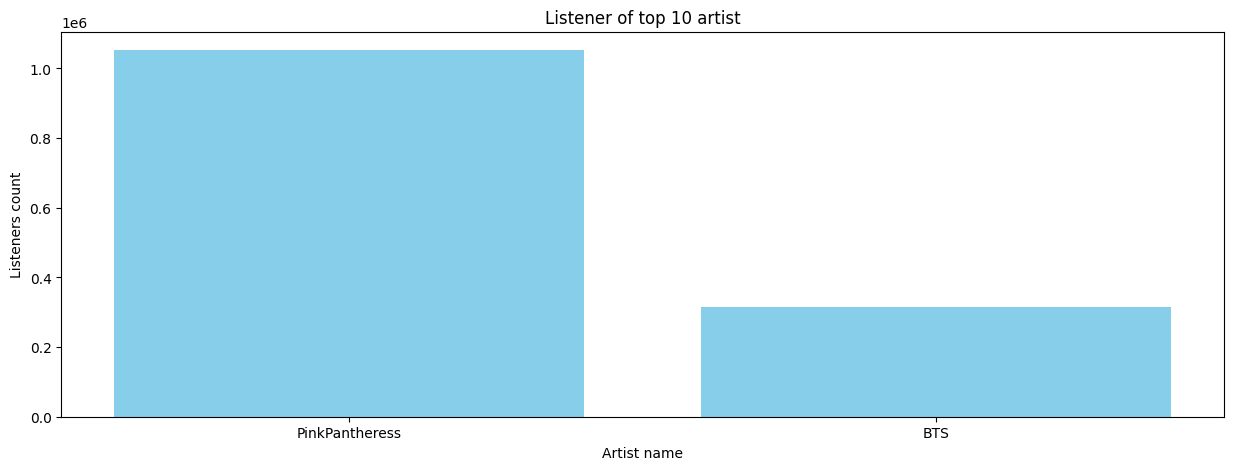

In [ ]:
# API Request + Cuestiones generales (antes 23/03/2026)
df_top10 = music.head(10)
df_top10['duration'] = pd.to_numeric(df_top10['duration'], errors='coerce')
df_top10['listeners'] = pd.to_numeric(df_top10['listeners'], errors='coerce')

df_top10['artist_name'] = df_top10['artist'].apply(lambda x: x['name'])

plt.figure(figsize = (15, 5))

plt.bar(df_top10['artist_name'], df_top10['listeners'], color = ['skyblue'])
plt.xlabel('Artist name')
plt.ylabel('Listeners count')
plt.title("Listener of top 10 artist")
plt.show()


#####  Top countries

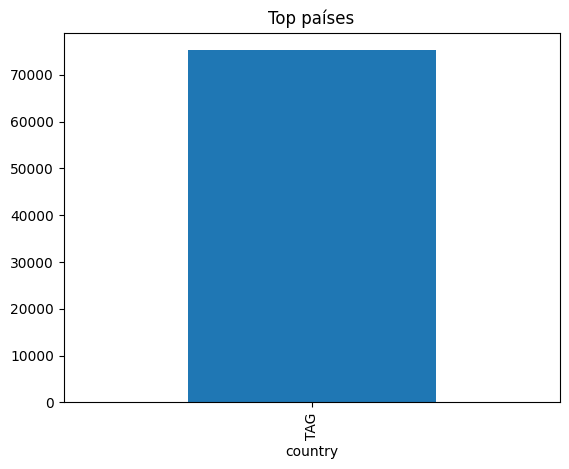

In [ ]:
top_countries = df_analysis['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top países")
plt.show()

> **Observaciones:** * que países dominan?... * existen sesgos de recoleccion?

#### (4) Géneros en crecimiento vs decrecimiento

In [ ]:
# API Request + Cuestiones generales (antes 23/03/2026)
def get_trending_tags(api_key):
    url = f"https://ws.audioscrobbler.com/2.0/?method=tag.getTopTags&api_key={api_key}&format=json"
    response = requests.get(url)
    return response.json()['toptags']['tag']

api_key = '63e059c3c912a3f642daf2372484d183'
get_trending_tags(api_key)
ret_generes = get_trending_tags(api_key)
top_generes = pd.DataFrame(ret_generes)[['name', 'count', 'reach']]
top_generes.head()


,name,count,reach
0,rock,4069604,402932
1,electronic,2499140,262240
2,seen live,2194765,82561
3,alternative,2131052,267219
4,pop,2082838,233783


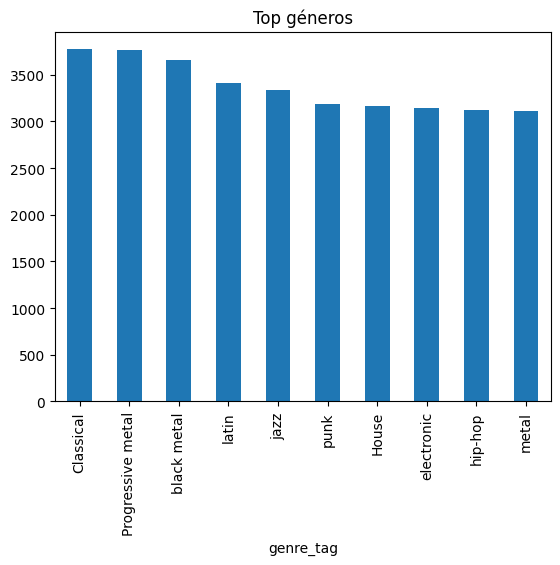

In [ ]:
top_genres = df_analysis['genre_tag'].value_counts().head(10)

top_genres.plot(kind='bar')
plt.title("Top géneros")
plt.show()

## integracion api acousticbrainz

In [ ]:
df_enriched = df_analysis.merge(df_acoustic, on='mbid', how='inner')

NameError: name 'df_acoustic' is not defined

In [ ]:
df_ab_analysis = df_enriched.dropna(subset=['bpm', 'danceability']).copy()

In [ ]:
print(df_ab_analysis.shape)

In [ ]:
plt.scatter(df_enriched['danceability'], df_enriched['playcount_log'])
plt.xlabel("Danceability")
plt.ylabel("Playcount (log)")
plt.show()

* BMP analisis

In [ ]:
plt.hist(df_enriched['bpm'], bins=30)
plt.title("Distribución BPM")
plt.show()

In [ ]:
plt.scatter(df_ab_analysis['bpm'], df_ab_analysis['playcount_log'])
plt.xlabel("BPM")
plt.ylabel("Popularidad")
plt.show()

* Danceability analisis

In [ ]:
plt.boxplot(df_ab_analysis['danceability'])
plt.title("Distribución Danceability")
plt.show()

* Género vs BPM


In [ ]:
df_ab_analysis.groupby('genre_tag')['bpm'].mean()

* Nuevas features [èngagement] 

Objetivo: Medir repetición de escucha

In [ ]:
df_analysis['engagement'] = df_analysis['playcount'] / df_analysis['listeners']
df_analysis.head()

,name,duration,playcount,listeners,streamable,artist,country,genre_tag,engagement
25013,Telephone (feat. Beyoncé),221,NaN,NaN,NaN,Lady Gaga,TAG,pop,NaN
25014,California Gurls (feat. Snoop Dogg),235,NaN,NaN,NaN,Katy Perry,TAG,pop,NaN
25015,Blow,219,NaN,NaN,NaN,Ke$ha,TAG,pop,NaN
25016,We Found Love (feat. Calvin Harris),216,NaN,NaN,NaN,Rihanna,TAG,pop,NaN
25017,Die Young,213,NaN,NaN,NaN,Ke$ha,TAG,pop,NaN


## Future engineering

### Duración promedio de top30 tracks:

In [ ]:
df_top30_duration = df_analysis.sort_values(by='playcount', ascending=False) # .head(30)
df_top30_duration.iloc[:30]
df_top30_duration.head()

df_top30_duration.loc[:, 'duration'] = pd.to_numeric(df_top30_duration['duration'], errors='coerce')
mean = df_top30_duration['duration'].mean()
mean


## API Request + Cuestiones generales (antes 23/03/2026)

In [ ]:
ret = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=chart.gettoptracks&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret.json()
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")
music = pd.DataFrame(ret.json()["tracks"]["track"])
music.head()
# Cleaning the data frame:
music.drop(['mbid', 'image', 'url'],axis=1)


Stateside + Zara Larsson . Duracion: 176 minutos
SWIM . Duracion: 159 minutos
Body to Body . Duracion: 189 minutos
Hooligan . Duracion: 182 minutos
FYA . Duracion: 180 minutos
Aliens . Duracion: 167 minutos
2.0 . Duracion: 169 minutos
Merry Go Round . Duracion: 229 minutos
NORMAL . Duracion: 181 minutos
Like Animals . Duracion: 189 minutos
they don’t know ’bout us . Duracion: 164 minutos
One More Night . Duracion: 167 minutos
Please . Duracion: 172 minutos
No. 29 . Duracion: 98 minutos
Into the Sun . Duracion: 227 minutos
Babydoll . Duracion: 97 minutos
Fame Is a Gun . Duracion: 183 minutos
Manchild . Duracion: 213 minutos
Dracula . Duracion: 205 minutos
Good Luck, Babe! . Duracion: 218 minutos
American Girls . Duracion: 213 minutos
The Less I Know the Better . Duracion: 234 minutos
Midnight Sun . Duracion: 189 minutos
End of Beginning . Duracion: 159 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
DtMF . Duracion: 164 minutos
Creep . Duracion: 235 minutos
See You Again (feat. Kal

,name,duration,playcount,listeners,streamable,artist
0,Stateside + Zara Larsson,176,15707598,1052707,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f..."
1,SWIM,159,27082198,316084,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
2,Body to Body,189,9850439,313086,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
3,Hooligan,182,9107733,289510,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
4,FYA,180,8932250,283295,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
5,Aliens,167,8791889,275610,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
6,2.0,169,8607049,265665,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
7,Merry Go Round,229,8369573,260410,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
8,NORMAL,181,9544468,257444,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."
9,Like Animals,189,8524945,255200,"{'#text': '0', 'fulltrack': '0'}","{'name': 'BTS', 'mbid': '0d79fe8e-ba27-4859-bb..."


#### Filtrando ds:

* Nombre y duracion de las canciones
* Comparación de la canción por titulo (happy or sad)
* Duración promedio de los top30 tracks


##### Nombre y duración de las canciones


In [ ]:
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")


Stateside + Zara Larsson . Duracion: 176 minutos
SWIM . Duracion: 159 minutos
Body to Body . Duracion: 189 minutos
Hooligan . Duracion: 182 minutos
FYA . Duracion: 180 minutos
Aliens . Duracion: 167 minutos
2.0 . Duracion: 169 minutos
Merry Go Round . Duracion: 229 minutos
NORMAL . Duracion: 181 minutos
Like Animals . Duracion: 189 minutos
they don’t know ’bout us . Duracion: 164 minutos
One More Night . Duracion: 167 minutos
Please . Duracion: 172 minutos
No. 29 . Duracion: 98 minutos
Into the Sun . Duracion: 227 minutos
Babydoll . Duracion: 97 minutos
Fame Is a Gun . Duracion: 183 minutos
Manchild . Duracion: 213 minutos
Dracula . Duracion: 205 minutos
Good Luck, Babe! . Duracion: 218 minutos
American Girls . Duracion: 213 minutos
The Less I Know the Better . Duracion: 234 minutos
Midnight Sun . Duracion: 189 minutos
End of Beginning . Duracion: 159 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
DtMF . Duracion: 164 minutos
Creep . Duracion: 235 minutos
See You Again (feat. Kal

##### Comparación de grupos (canciones 'happy'-'sad'):

In [ ]:
df_happy = music[music['name'].str.contains('happy',case=False,na=False)]
df_happy.count()
df_sad = music[music['name'].str.contains('sad', case=False, na=False)]
df_sad.count()


name          0
duration      0
playcount     0
listeners     0
mbid          0
url           0
streamable    0
artist        0
image         0
dtype: int64

# **ML**

1. **Definición del problema:** 

* Regresión → predecir popularidad (0–100)

* Clasificación → hit vs no hit

2. **Modelos básicos (mínimo viable):** (1) Linear Regression; (2) Random Forest; (3) XGBoost / LightGBM

3. **Evaluación:** (1) RMSE / MAE (regresión); (2) Accuracy / F1 (clasificación)

4. **Interpretabilidad:**

* Feature importance

* SHAP values (muy top para destacar)